In [1]:
%load_ext autoreload 
#hopefully this will reload the modules when they are changed specifically when i change the plotting modules
%autoreload 2

In [2]:
from myproject.redshiftGalaxyAnalysis import GalaxyAnalysis

In [19]:
galaxyAnalysisSDSS = GalaxyAnalysis(generalRewrite=True)
galaxyAnalysisDefault = GalaxyAnalysis(generalRewrite=True, luminosityType='Default')


Be sure that all the galaxies are cosmological in origin.  That is, be sure that the relevant flag is “1”.   How many galaxies, in total, do you find for the entire simulation when you use the original magnitudes?  How many galaxies, in total, do you find for the entire simulation when you use the supplemental SDSS magnitudes? These, of course, should be the same.

In [4]:
print(f"number of galaxies in SDSS: {len(galaxyAnalysisSDSS.loaded_list_of_galaxy_groups.getAllGalaxyGroups())}")
print(f"number of galaxies in Default: {len(galaxyAnalysisDefault.loaded_list_of_galaxy_groups.getAllGalaxyGroups())}")

print(f"number of galaxies in SDSSraw: {len(galaxyAnalysisSDSS.loaded_list_of_galaxy_groupsRaw.getAllGalaxyGroups())}")

number of galaxies in SDSS: 3733
number of galaxies in Default: 3733
number of galaxies in SDSSraw: 3733


In [5]:
#print the number of members for each galaxy group of default
for gg in galaxyAnalysisDefault.filtered_gt14_list_of_galaxy_groups.getAllGalaxyGroups():
    print(f"number of members for galaxy group {gg.group_id}: {len(gg.getSubhalos())}") if len(gg.getSubhalos()) < 50 else None

number of members for galaxy group 190: 45
number of members for galaxy group 228: 49
number of members for galaxy group 298: 28
number of members for galaxy group 306: 46
number of members for galaxy group 307: 48
number of members for galaxy group 336: 44
number of members for galaxy group 343: 48
number of members for galaxy group 348: 47


# luminosity function

Using all the galaxies in the simulation, make a plot of the number of galaxies per unit volume, per unit r-band magnitude.  That’s the luminosity function.  Do this for both the original magnitudes and the supplemental SDSS magnitudes.  What I’m interested to see is whether the “downturn” in the number of galaxies at the faint end happens at a different value in the supplemental catalog than it does for the original catalog.  If so, you might be inadvertently dipping down too faint and are encountering issues that could be related to small galaxies not being well-resolved. My instincts tell me this shouldn’t be the case – because you’re finding MORE satellites using the supplemental magnitudes, and all dust does is make things fainter (i.e., drives them to have magnitudes that are GREATER than they would be in the original catalog) and redder.  So, if anything, the supplemental magnitudes should give you fewer satellites overall, and specifically fewer blue satellites. 

In [83]:
# make a plot of the number of galaxies per unit volume, per unit r-band magnitude.  That’s the luminosity function
L=205*1e3
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup
import numpy as np
import matplotlib.pyplot as plt
def plot_luminosity_function(list_gg:ListGalaxyGroup, plot_dirc:str='', label=None,
                             color=None, hist_kwargs=None, ax=None):
    rmags = []
    for gg in list_gg.getAllGalaxyGroups():
        for galaxy in gg.getSubhalos():
            rmags.append(galaxy.getRbandMagnitude()) if label=='SDSS' else rmags.append(galaxy.getDefaultRbandMagnitude())
    
    bins ='auto'
    xlow=-23
    xhigh=-7
    bins = np.linspace(xlow, xhigh, 100)
    volume =L**3
    print(f"unit volume used: {volume}")
    # print(f"rmags: {rmags}")
    
    mags = np.asarray(rmags)
    hist, edges = np.histogram(mags, bins=bins)
    width = np.diff(edges)
    values = hist.astype(float) / width
    if volume is not None:
        values = values / float(volume)
    centers = edges[:-1] + 0.5 * width
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,5))
    hk = {} if hist_kwargs is None else dict(hist_kwargs)
    ax.step(centers, values, where='mid', label=label, color=color, **hk)
    ax.set_xlabel('r-band magnitude')
    ylabel = 'Number / mag / L^3'
    title = 'Luminosity Function'
    ax.set_ylabel(ylabel)
    ax.legend(loc='upper right')
    ax.set_title(title)
    ax.invert_xaxis()
    ax.set_xlim(xlow, xhigh)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    return centers, values

unit volume used: 8615125000000000.0
unit volume used: 8615125000000000.0


(array([-22.91919192, -22.75757576, -22.5959596 , -22.43434343,
        -22.27272727, -22.11111111, -21.94949495, -21.78787879,
        -21.62626263, -21.46464646, -21.3030303 , -21.14141414,
        -20.97979798, -20.81818182, -20.65656566, -20.49494949,
        -20.33333333, -20.17171717, -20.01010101, -19.84848485,
        -19.68686869, -19.52525253, -19.36363636, -19.2020202 ,
        -19.04040404, -18.87878788, -18.71717172, -18.55555556,
        -18.39393939, -18.23232323, -18.07070707, -17.90909091,
        -17.74747475, -17.58585859, -17.42424242, -17.26262626,
        -17.1010101 , -16.93939394, -16.77777778, -16.61616162,
        -16.45454545, -16.29292929, -16.13131313, -15.96969697,
        -15.80808081, -15.64646465, -15.48484848, -15.32323232,
        -15.16161616, -15.        , -14.83838384, -14.67676768,
        -14.51515152, -14.35353535, -14.19191919, -14.03030303,
        -13.86868687, -13.70707071, -13.54545455, -13.38383838,
        -13.22222222, -13.06060606, -12.

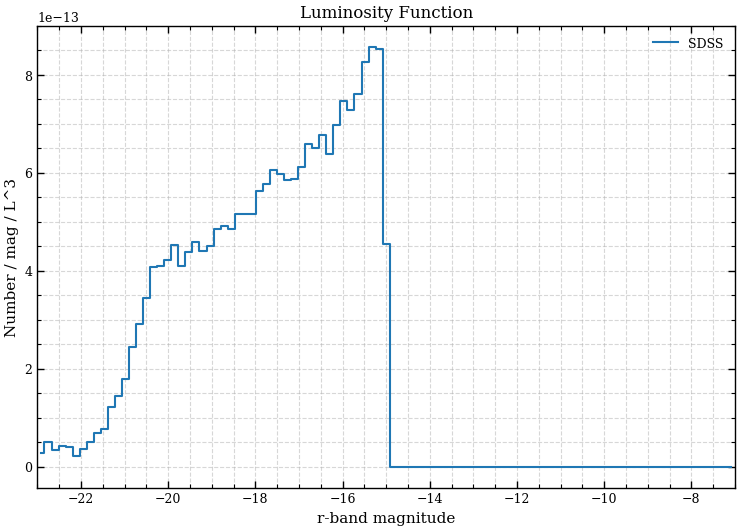

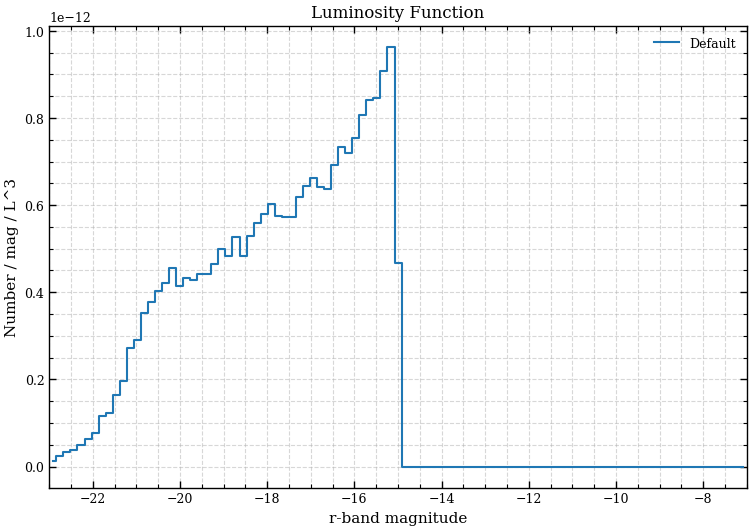

In [89]:
figSDSS, axSDSS = plt.subplots(figsize=(9,6))
plot_luminosity_function(galaxyAnalysisSDSS.filtered_gt14_list_of_galaxy_groups, ax=axSDSS, label='SDSS')

figDEFAULT, axDEFAULT = plt.subplots(figsize=(9,6))
plot_luminosity_function(galaxyAnalysisDefault.filtered_gt14_list_of_galaxy_groups, ax=axDEFAULT, label='Default')


(<Figure size 900x600 with 2 Axes>,
 <Axes: title={'center': 'r-band shift'}, xlabel='r-band (SDSS - Default)', ylabel='Number'>,
 <Axes: title={'center': 'g-band shift'}, xlabel='g-band (SDSS - Default)', ylabel='Number'>)

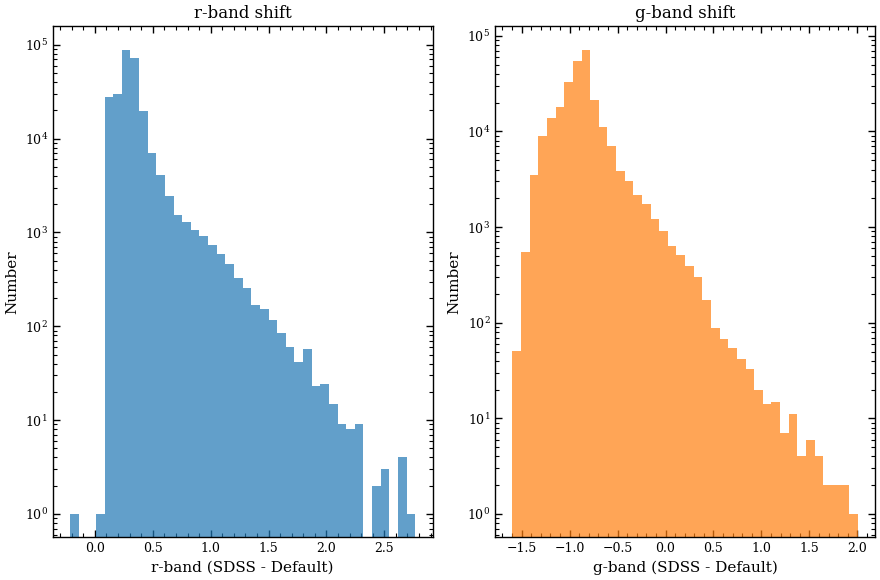

In [96]:
# see hist of how much a galaxies r and g band have shifted
def plot_shift_in_band(list_gg_sdss:ListGalaxyGroup, list_gg_default:ListGalaxyGroup, label=None, color=None):
    rmagSDSS = []
    gmagSDSS = []
    for gg in list_gg_sdss.getAllGalaxyGroups():
        for galaxy in gg.getSubhalos():
            rmagSDSS.append(galaxy.getRbandMagnitude())
            gmagSDSS.append(galaxy.getGbandMagnitude())
    rmagDefault = []
    gmagDefault = []
    for gg in list_gg_default.getAllGalaxyGroups():
        for galaxy in gg.getSubhalos():
            rmagDefault.append(galaxy.getDefaultRbandMagnitude())
            gmagDefault.append(galaxy.getDefaultGbandMagnitude())

    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(9,6))
    # plot histograms of the shifts
    rshift = np.array(rmagSDSS) - np.array(rmagDefault)
    gshift = np.array(gmagSDSS) - np.array(gmagDefault)

    ax1.hist(rshift, bins=40, color=color or 'C0', alpha=0.7)
    ax1.set_xlabel('r-band (SDSS - Default)')
    ax1.set_ylabel('Number')
    ax1.set_title('r-band shift')
    ax1.set_yscale('log')

    ax2.hist(gshift, bins=40, color=color or 'C1', alpha=0.7)
    ax2.set_xlabel('g-band (SDSS - Default)')
    ax2.set_ylabel('Number')
    ax2.set_title('g-band shift')
    ax2.set_yscale('log')

    fig.tight_layout()
    return fig, ax1, ax2
#for all galaxies
plot_shift_in_band(list_gg_sdss=galaxyAnalysisSDSS.loaded_list_of_galaxy_groupsRaw, list_gg_default=galaxyAnalysisDefault.loaded_list_of_galaxy_groupsRaw)
#for cluster galaxies

In [92]:
# make a plot of the number of galaxies per unit volume, per unit r-band magnitude.  That’s the luminosity function
L=205*1e3
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup
import numpy as np
import matplotlib.pyplot as plt
def plot_luminosity_function2(list_gg:ListGalaxyGroup, list_gg2:ListGalaxyGroup, plot_dirc:str='', label=None, label2=None,
                             color=None, hist_kwargs=None, ax=None):
    rmags = []
    for gg in list_gg.getAllGalaxyGroups():
        for galaxy in gg.getSubhalos():
            rmags.append(galaxy.getRbandMagnitude())
    rmags2 = []
    for gg in list_gg2.getAllGalaxyGroups():
        for galaxy in gg.getSubhalos():
            rmags2.append(galaxy.getDefaultRbandMagnitude())
    
    bins ='auto'
    xlow=-23
    xhigh=-7
    bins = np.linspace(xlow, xhigh, 100)
    volume =L**3
    print(f"unit volume used: {volume}")
    # print(f"rmags: {rmags}")
    
    mags = np.asarray(rmags)
    hist, edges = np.histogram(mags, bins=bins)
    width = np.diff(edges)
    values = hist.astype(float) / width
    if volume is not None:
        values = values / float(volume)
    centers = edges[:-1] + 0.5 * width
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,5))
    hk = {} if hist_kwargs is None else dict(hist_kwargs)
    ax.step(centers, values, where='mid', label=label, color=color, **hk)


    mags2 = np.asarray(rmags2)
    hist2, edges2 = np.histogram(mags2, bins=bins)
    width2 = np.diff(edges2)
    values2 = hist2.astype(float) / width2
    if volume is not None:
        values2 = values2 / float(volume)
    centers2 = edges2[:-1] + 0.5 * width2
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,5))
    hk = {} if hist_kwargs is None else dict(hist_kwargs)
    ax.step(centers2, values2, where='mid', label=label2, color=color, **hk)

    ax.set_xlabel('r-band magnitude')
    ylabel = 'Number / mag / L^3'
    title = 'Luminosity Function'
    ax.set_ylabel(ylabel)
    ax.legend(loc='upper right')
    ax.set_title(title)
    ax.invert_xaxis()
    ax.set_yscale('log')
    ax.set_xlim(xlow, xhigh)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    return centers, values

unit volume used: 8615125000000000.0


(array([-22.91919192, -22.75757576, -22.5959596 , -22.43434343,
        -22.27272727, -22.11111111, -21.94949495, -21.78787879,
        -21.62626263, -21.46464646, -21.3030303 , -21.14141414,
        -20.97979798, -20.81818182, -20.65656566, -20.49494949,
        -20.33333333, -20.17171717, -20.01010101, -19.84848485,
        -19.68686869, -19.52525253, -19.36363636, -19.2020202 ,
        -19.04040404, -18.87878788, -18.71717172, -18.55555556,
        -18.39393939, -18.23232323, -18.07070707, -17.90909091,
        -17.74747475, -17.58585859, -17.42424242, -17.26262626,
        -17.1010101 , -16.93939394, -16.77777778, -16.61616162,
        -16.45454545, -16.29292929, -16.13131313, -15.96969697,
        -15.80808081, -15.64646465, -15.48484848, -15.32323232,
        -15.16161616, -15.        , -14.83838384, -14.67676768,
        -14.51515152, -14.35353535, -14.19191919, -14.03030303,
        -13.86868687, -13.70707071, -13.54545455, -13.38383838,
        -13.22222222, -13.06060606, -12.

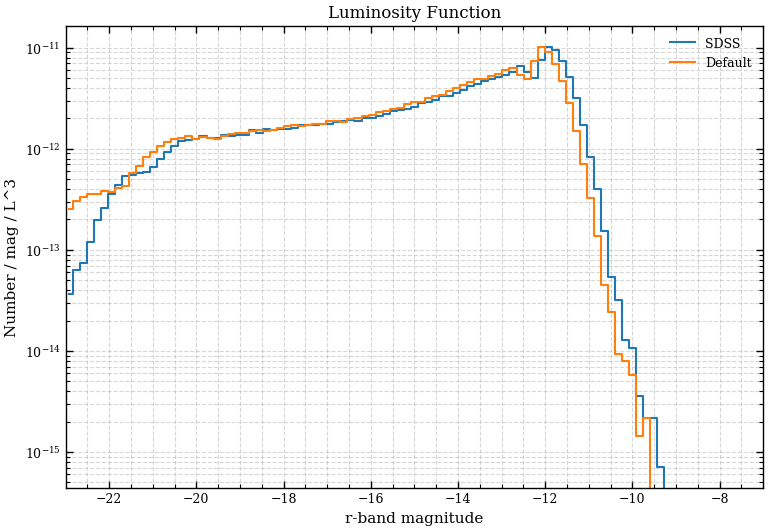

In [94]:
figBoth, axBoth = plt.subplots(figsize=(9,6))
plot_luminosity_function2(galaxyAnalysisSDSS.loaded_list_of_galaxy_groupsRaw, galaxyAnalysisDefault.loaded_list_of_galaxy_groupsRaw, ax=axBoth, label='SDSS', label2='Default')



# save file for Prof

I know this will be a huge file, but there will be room to dump it into the OneDrive folder.  Make a file where each line of the file corresponds to an individual galaxy (of cosmological origin) and the columns are: 1) x-coordinate in the database, 2) y-coordinate in the database, 3) z-coordinate in the database, 4) g-band magnitude from the supplemental catalog, 5) r-band magnitude from the supplemental catalog.  I’d like to play around with that file a bit myself to see if I can reproduce your intriguing P(Delta phi) results.  I think you have write permission for the OneDrive folder that has all the background reading info in it.  If it doesn’t allow you to write, let me know and we’ll figure out another way for me to get the file.

In [78]:
#save the SDDS's galaxy groups id, x, y, z, g, r to a txt file
with open('galaxy_groups_SDSS.txt', 'w') as f:
    f.write('group id\tid\tx\ty\tz\tg\tr\n')
    for galaxy_group in galaxyAnalysisSDSS.loaded_list_of_galaxy_groups.getAllGalaxyGroups():
        for galaxy in galaxy_group.getSubhalos():
            f.write(f"{galaxy_group.getGroupID()}\t{galaxy.getIdx()}\t{galaxy.getPosition()[0]}\t{galaxy.getPosition()[1]}\t{galaxy.getPosition()[2]}\t{galaxy.getGbandMagnitude()}\t{galaxy.getRbandMagnitude()}\n")

# check MRL

Use only the 280 most massive clusters and the original magnitudes (not the supplemental magnitudes).  From those, tell me what % of all clusters have an MRL value that is larger than that of a random sample more than 90% of the time, more than 95% of the time, more than 99% of the time, and more than 99.9% of the time.  Then, do the same thing, separately, for the small clusters (< 50 members in the original 280 clusters) and the big clusters (> 150 members).  Before we do anything else with this statistic, I want to be sure you can reproduce the results that I came up with last fall (and which I haven’t given you yet, so you don’t know the answer in advance).  


Resuming from existing temp file: MRL_values_280.hdf5

Final save after processing all galaxy groups.
99th percentile MRL: 0.24755314202963055tion for Galaxy Group 280 / 280 with 74 satellitess
Overall number of MRL values above 99th percentile: 27 out of 600


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,
/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:247: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_smooth, spline(x_smooth),'k--', alpha=0.5, linewidth=3, c=scatter_color, label=label)


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/MRL_distribution_curves_overlay_MRLDistribution_gt14_default_99.png_TNG300-1_z0p0
Resuming from existing temp file: MRL_values_280.hdf5

Final save after processing all galaxy groups.
99th percentile MRL: 0.19178925767765834tion for Galaxy Group 280 / 280 with 74 satellitess
Overall number of MRL values above 99th percentile: 69 out of 600


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,
/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:247: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_smooth, spline(x_smooth),'k--', alpha=0.5, linewidth=3, c=scatter_color, label=label)


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/MRL_distribution_curves_overlay_MRLDistribution_gt14_default_95.png_TNG300-1_z0p0
Resuming from existing temp file: MRL_values_280.hdf5

Final save after processing all galaxy groups.
99th percentile MRL: 0.19131656253837726tion for Galaxy Group 280 / 280 with 74 satellitess
Overall number of MRL values above 99th percentile: 71 out of 600


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,
/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:247: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_smooth, spline(x_smooth),'k--', alpha=0.5, linewidth=3, c=scatter_color, label=label)


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/MRL_distribution_curves_overlay_MRLDistribution_gt14_default_90.png_TNG300-1_z0p0
total to process: 280
Number of galaxy groups with more than 150 satellites: 52
total to process: 280
Number of galaxy groups with less than 50 satellites: 9
Resuming from existing temp file: MRL_values_280.hdf5

Final save after processing all galaxy groups.
choosing ax, 0essing random MRL distribution for Galaxy Group 52 / 52 with 338 satellites
99th percentile MRL: 0.1538902285418849
Overall number of MRL values above 99th percentile: 208 out of 840


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,
/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:247: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_smooth, spline(x_smooth),'k--', alpha=0.5, linewidth=3, c=scatter_color, label=label)


Resuming from existing temp file: MRL_values_0.hdf5
Progress: Processing Galaxy Group 9 / 9 with 47 satellites
Final save after processing all galaxy groups.
choosing ax, 1essing random MRL distribution for Galaxy Group 9 / 9 with 47 satellites
99th percentile MRL: 0.3347569377393958
Overall number of MRL values above 99th percentile: 0 out of 27
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/MRL_distribution_curves_overlay_MRLDistribution_gt14_default_99_member_difference_TNG300-1_z0p0


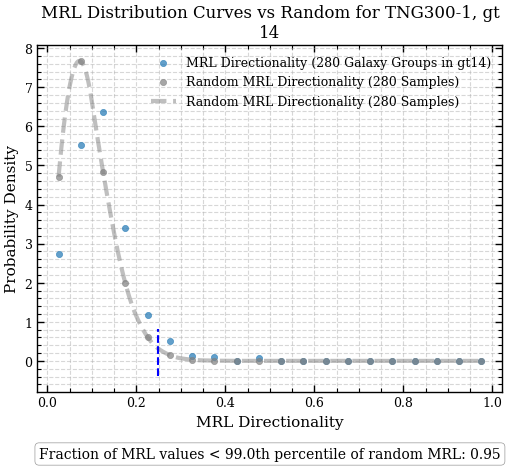

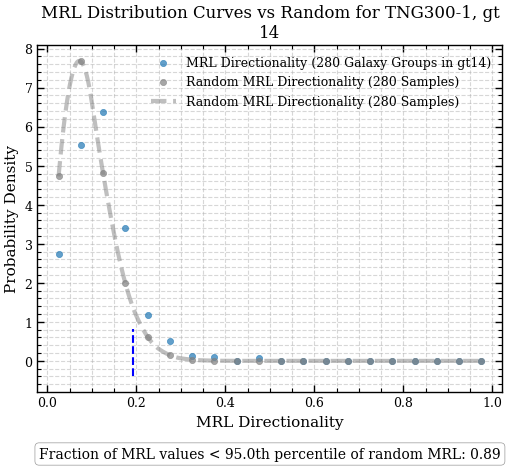

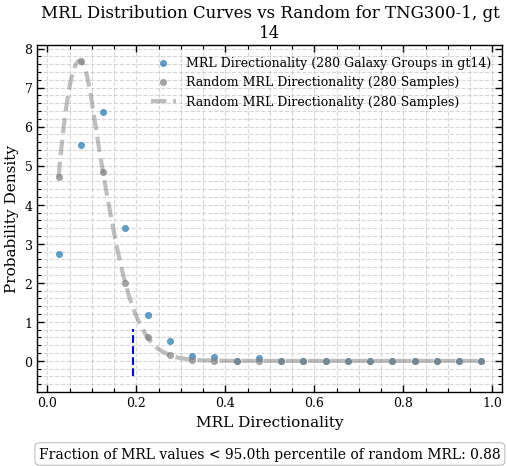

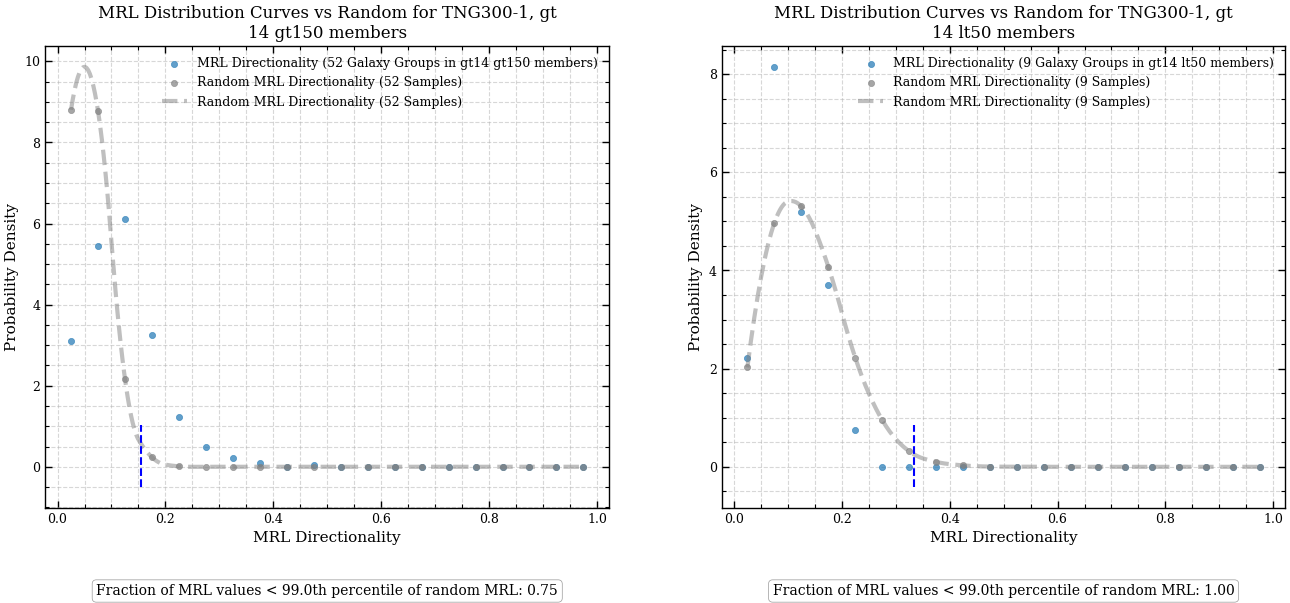

In [87]:
galaxyAnalysisDefault.setGeneralRewrite(False)
#compute MRL distribution plots for only gt14 of default
galaxyAnalysisDefault.overlayMRLAndMRLRandom([(galaxyAnalysisDefault.filtered_gt14_list_of_galaxy_groups, 'gt14')], filename='MRLDistribution_gt14_default_99.png', percentageMRL = 0.99*100)

galaxyAnalysisDefault.overlayMRLAndMRLRandom([(galaxyAnalysisDefault.filtered_gt14_list_of_galaxy_groups, 'gt14')], filename='MRLDistribution_gt14_default_95.png', percentageMRL = 0.95*100)

galaxyAnalysisDefault.overlayMRLAndMRLRandom([(galaxyAnalysisDefault.filtered_gt14_list_of_galaxy_groups, 'gt14')], filename='MRLDistribution_gt14_default_90.png', percentageMRL = 0.95*100)

#get gt150 members
filtered_GT150_list_of_galaxy_groups = galaxyAnalysisDefault.filtered_gt14_list_of_galaxy_groups.getFilterSubhalos(minNumGalaxies=150)
print(f'Number of galaxy groups with more than 150 satellites: {filtered_GT150_list_of_galaxy_groups.getNumGalaxyGroups()}')
filtered_LT50_list_of_galaxy_groups = galaxyAnalysisDefault.filtered_gt14_list_of_galaxy_groups.getFilterSubhalos(maxNumGalaxies=50)
print(f'Number of galaxy groups with less than 50 satellites: {filtered_LT50_list_of_galaxy_groups.getNumGalaxyGroups()}')

galaxyAnalysisDefault.overlayMRLAndMRLRandom([(filtered_GT150_list_of_galaxy_groups, 'gt14 gt150 members'), (filtered_LT50_list_of_galaxy_groups, 'gt14 lt50 members')], filename='MRLDistribution_gt14_default_99_member_difference', percentageMRL=0.99*100)
galaxyAnalysisDefault.setGeneralRewrite(True)

# double check p(deltaphi)

Total Galaxy Groups to process: 280 with pairs : 2338502
Processing Subhalo 70/70 in Galaxy Group ID 197 with total pairs 241595
Intermediate save after processing 100 galaxy groups.
Processing Subhalo 179/179 in Galaxy Group ID 32 with total pairs 15931
Intermediate save after processing 200 galaxy groups.
Processing Subhalo 66/66 in Galaxy Group ID 99 with total pairs 2145261
Final save after processing all galaxy groups.
Accumulating results from saved batches...
warning ax is none


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/pairwise_polar/pairwise_polar_difference_TNG300-1_z0p0
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/color_distribution_TNG300-1_z0p0
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/color_distribution_TNG300-1_z0p0
total to process: 280
Number of galaxy groups with only red satellites: (0, 0)
total to process: 280
Number of galaxy groups with only blue satellites: (23, 604)
Total Galaxy Groups to process: 0 with pairs : 0

Final save after processing all galaxy groups.
Accumulating results from saved batches...
Total Galaxy Groups to process: 280 with pairs : 2338502
Processing Subhalo 70/70 in Galaxy Group ID 197 with total pairs 241595
Intermediate save after processing 100 galaxy groups.
Processing Subhalo 179/179 in Galaxy Group ID 32 with total pairs 15931
Intermediate save after processing 200 galaxy groups.
Processing Subhalo 66/66 in Galaxy Group ID 99 with total pairs 2145261
F

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/pairwise_polar/pairwise_polar_difference_red_blue_TNG300-1_z0p0
data to be saved: [[5.00000000e+00 6.53907745e-03 5.11330653e-05 6.75911610e-03
  3.12371511e-05]
 [1.50000000e+01 6.33831735e-03 5.03420131e-05 6.08384834e-03
  2.96357318e-05]
 [2.50000000e+01 6.10792904e-03 4.94186162e-05 5.66616573e-03
  2.86003338e-05]
 [3.50000000e+01 5.81580531e-03 4.82223663e-05 5.50300778e-03
  2.81855510e-05]
 [4.50000000e+01 5.60632868e-03 4.73459534e-05 5.37315415e-03
  2.78510207e-05]
 [5.50000000e+01 5.42156222e-03 4.65592324e-05 5.27569536e-03
  2.75972826e-05]
 [6.50000000e+01 5.28973469e-03 4.59896954e-05 5.23362826e-03
  2.74870354e-05]
 [7.50000000e+01 5.18341700e-03 4.55251791e-05 5.39607884e-03
  2.79103710e-05]
 [8.50000000e+01 5.12743928e-03 4.52786898e-05 5.73029134e-03
  2.87617176e-05]
 [9.50000000e+01 5.08493620e-03 4.50906340e-05 5.70033622e-03
  2.86864431e-05]
 [1.05000000e+02 5.10884668e-03 4.51965227e-05 5.3355

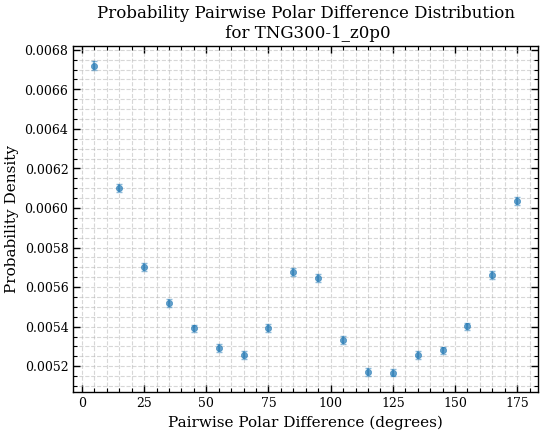

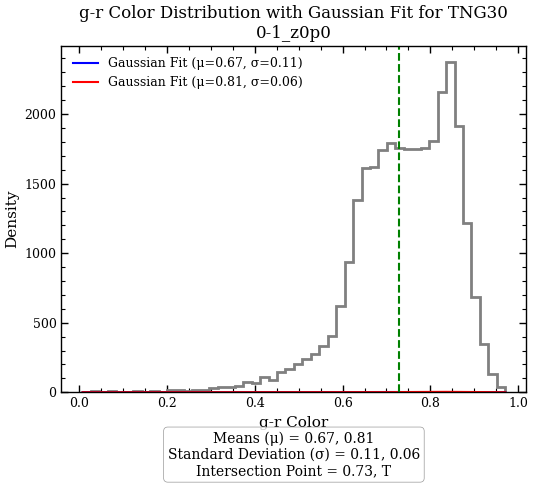

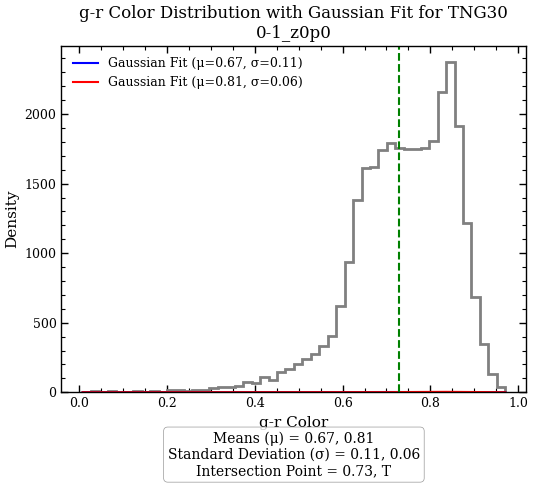

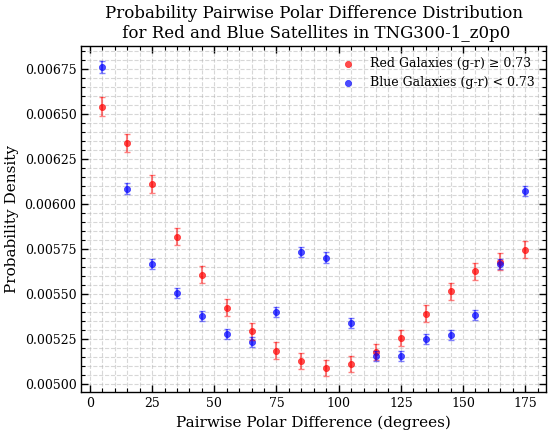

In [97]:
galaxyAnalysisSDSS.setGeneralRewrite(True)
galaxyAnalysisSDSS.pairwisePolarDifferencePlot(galaxyAnalysisSDSS.filtered_gt14_list_of_galaxy_groups)
galaxyAnalysisSDSS.redVsBlueDistributionPlot(galaxyAnalysisSDSS.filtered_gt14_list_of_galaxy_groups)
galaxyAnalysisSDSS.redVsBluePairwisePlot(galaxyAnalysisSDSS.filtered_gt14_list_of_galaxy_groups)
galaxyAnalysisSDSS.setGeneralRewrite(False)

In [ ]:
print(galaxyAnalysisDefault.loaded_list_of_galaxy_groupsRaw.getNumGalaxyGroups())
print(galaxyAnalysisDefault.loaded_list_of_galaxy_groupsRaw.getGalaxyGroupI(0).getNumSubhalos())
print(galaxyAnalysisDefault.loaded_list_of_galaxy_groupsRaw.getGalaxyGroupI(0).getSubhaloI(5).getFlag())
print(galaxyAnalysisDefault.loaded_list_of_galaxy_groupsRaw.getGalaxyGroupI(1000).getNumSubhalos())

NameError: name 'galaxyAnalysisDefault' is not defined

Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/color_distribution_TNG300-1_z0p0
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/color_distribution_TNG300-1_z0p0
total to process: 280
Number of galaxy groups with only red satellites: (0, 0)
total to process: 280
Number of galaxy groups with only blue satellites: (27, 659)
Total Galaxy Groups to process: 0 with pairs : 0

Final save after processing all galaxy groups.
Accumulating results from saved batches...
Total Galaxy Groups to process: 280 with pairs : 2765705
Processing Subhalo 78/78 in Galaxy Group ID 197 with total pairs 300326
Intermediate save after processing 100 galaxy groups.
Processing Subhalo 192/192 in Galaxy Group ID 32 with total pairs 18336
Intermediate save after processing 200 galaxy groups.
Processing Subhalo 73/73 in Galaxy Group ID 99 with total pairs 2628918
Final save after processing all galaxy groups.
Accumulating results from saved batches...
Computed pairwise polar differe

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/pairwise_polar/pairwise_polar_difference_red_blue_TNG300-1_z0p0
data to be saved: [[5.00000000e+00 6.53907745e-03 5.11330653e-05 6.74957105e-03
  2.86886883e-05]
 [1.50000000e+01 6.33831735e-03 5.03420131e-05 6.08087799e-03
  2.72305084e-05]
 [2.50000000e+01 6.10792904e-03 4.94186162e-05 5.65966160e-03
  2.62704696e-05]
 [3.50000000e+01 5.81580531e-03 4.82223663e-05 5.50092046e-03
  2.58994348e-05]
 [4.50000000e+01 5.60632868e-03 4.73459534e-05 5.37390805e-03
  2.55986888e-05]
 [5.50000000e+01 5.42156222e-03 4.65592324e-05 5.27939256e-03
  2.53725772e-05]
 [6.50000000e+01 5.28973469e-03 4.59896954e-05 5.23584789e-03
  2.52677235e-05]
 [7.50000000e+01 5.18341700e-03 4.55251791e-05 5.39340621e-03
  2.56450866e-05]
 [8.50000000e+01 5.12743928e-03 4.52786898e-05 5.73870292e-03
  2.64532768e-05]
 [9.50000000e+01 5.08493620e-03 4.50906340e-05 5.70316969e-03
  2.63712522e-05]
 [1.05000000e+02 5.10884668e-03 4.51965227e-05 5.3431

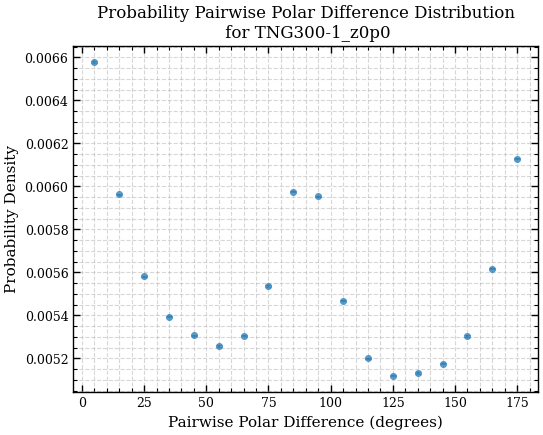

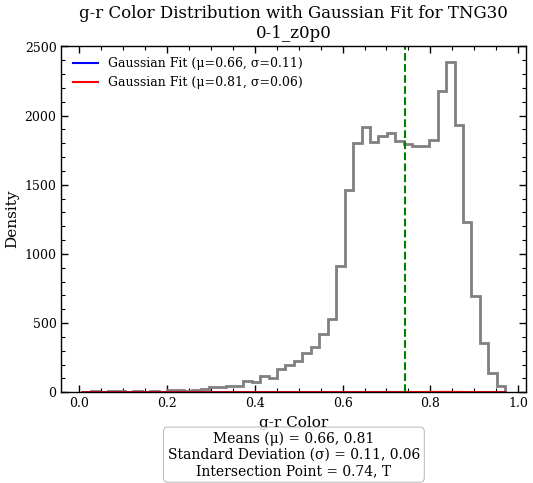

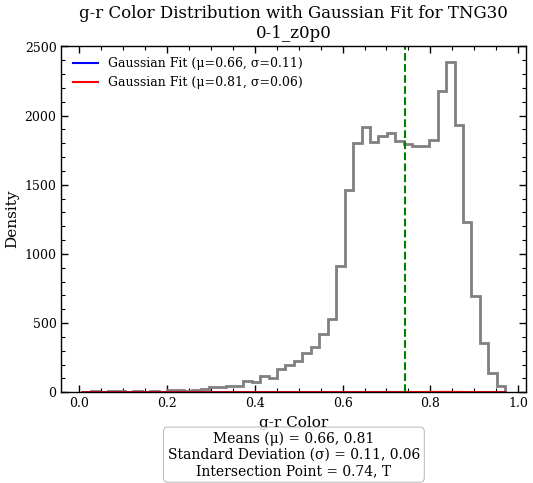

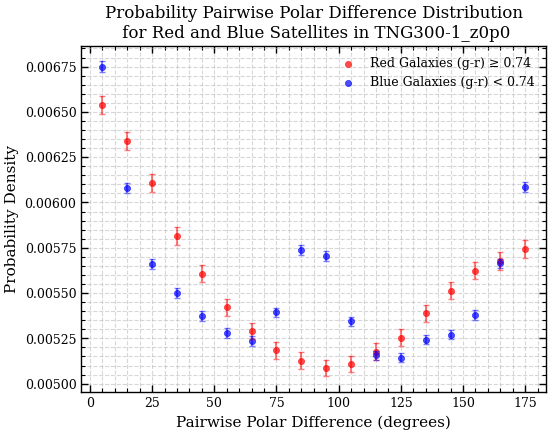

In [7]:
galaxyAnalysisDefault.setGeneralRewrite(True)
galaxyAnalysisDefault.pairwisePolarDifferencePlot(galaxyAnalysisDefault.loaded_list_of_galaxy_groupsRaw)
galaxyAnalysisDefault.redVsBlueDistributionPlot(galaxyAnalysisDefault.filtered_gt14_list_of_galaxy_groups)
galaxyAnalysisDefault.redVsBluePairwisePlot(galaxyAnalysisDefault.filtered_gt14_list_of_galaxy_groups)
galaxyAnalysisDefault.setGeneralRewrite(False)

In [14]:
galaxyAnalysisOriginal = GalaxyAnalysis(generalRewrite=True, luminosityType='Default')

Progress: 3732/3732
Loaded 3732 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p0/data/galaxy_data_TNG300-1.hdf5
total to process: 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732


In [15]:
#check the number of galaxy groups loaded
print(f'Number of galaxy groups loaded: {galaxyAnalysisOriginal.loaded_list_of_galaxy_groupsRaw.getNumGalaxyGroups()}')
print(f"Number of subhalos in GG 0: {galaxyAnalysisOriginal.loaded_list_of_galaxy_groupsRaw.getGalaxyGroupI(0).getNumSubhalos()}")
print(f"Number of subhalos in GG 10: {galaxyAnalysisOriginal.loaded_list_of_galaxy_groupsRaw.getGalaxyGroupI(10).getNumSubhalos()}")
print(f' Range of satellites: {galaxyAnalysisOriginal.loaded_list_of_galaxy_groupsRaw.getRangeOfNumSubhalos()}')

Number of galaxy groups loaded: 3732
Number of subhalos in GG 0: 598
Number of subhalos in GG 10: 21
 Range of satellites: (1, 597)


In [18]:
#check the number of galaxy groups loaded
print(f'Number of galaxy groups loaded: {galaxyAnalysisOriginal.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups()}')
print(f"Number of subhalos in GG 0: {galaxyAnalysisOriginal.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(0).getNumSubhalos()}")
print(f"Number of subhalos in GG 10: {galaxyAnalysisOriginal.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(10).getNumSubhalos()}")
print(f' Range of satellites: {galaxyAnalysisOriginal.filtered_gt14_list_of_galaxy_groups.getRangeOfNumSubhalos()}')

Number of galaxy groups loaded: 280
Number of subhalos in GG 0: 598
Number of subhalos in GG 10: 98
 Range of satellites: (31, 597)


Total Galaxy Groups to process: 3732 with pairs : 2549893
Processing Subhalo 35/597 in Galaxy Group ID 0 with total pairs 177906

Processing Subhalo 15/15 in Galaxy Group ID 1087 with total pairs 10528
Intermediate save after processing 100 galaxy groups.
Processing Subhalo 15/15 in Galaxy Group ID 1177 with total pairs 10550
Intermediate save after processing 200 galaxy groups.
Processing Subhalo 14/14 in Galaxy Group ID 1267 with total pairs 91678
Intermediate save after processing 300 galaxy groups.
Processing Subhalo 17/17 in Galaxy Group ID 1359 with total pairs 13678
Intermediate save after processing 400 galaxy groups.
Processing Subhalo 9/9 in Galaxy Group ID 1449 with total pairs 3691590
Intermediate save after processing 500 galaxy groups.
Processing Subhalo 10/10 in Galaxy Group ID 1540 with total pairs 45000
Intermediate save after processing 600 galaxy groups.
Processing Subhalo 14/14 in Galaxy Group ID 1633 with total pairs 91645
Intermediate save after processing 700 galaxy groups.
Processing Subhalo 14/14 in Galaxy Group ID 1723 with total pairs 91186
Intermediate save after processing 800 galaxy 

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/pairwise_polar/pairwise_polar_difference_TNG300-1_z0p0
Total Galaxy Groups to process: 280 with pairs : 2068402
Processing Subhalo 66/66 in Galaxy Group ID 197 with total pairs 214528
Intermediate save after processing 100 galaxy groups.
Processing Subhalo 168/168 in Galaxy Group ID 32 with total pairs 14028
Intermediate save after processing 200 galaxy groups.
Processing Subhalo 57/57 in Galaxy Group ID 99 with total pairs 1596210
Final save after processing all galaxy groups.
Accumulating results from saved batches...
warning ax is none


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/pairwise_polar/pairwise_polar_difference_TNG300-1_z0p0
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/color_distribution_TNG300-1_z0p0
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/color_distribution_TNG300-1_z0p0
total to process: 280
Number of galaxy groups with only red satellites: (0, 0)
total to process: 280
Number of galaxy groups with only blue satellites: (31, 597)
Total Galaxy Groups to process: 0 with pairs : 0

Final save after processing all galaxy groups.
Accumulating results from saved batches...
Total Galaxy Groups to process: 280 with pairs : 2068402
Processing Subhalo 66/66 in Galaxy Group ID 197 with total pairs 214528
Intermediate save after processing 100 galaxy groups.
Processing Subhalo 168/168 in Galaxy Group ID 32 with total pairs 14028
Intermediate save after processing 200 galaxy groups.
Processing Subhalo 57/57 in Galaxy Group ID 99 with total pairs 1596210
F

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/pairwise_polar/pairwise_polar_difference_red_blue_TNG300-1_z0p0
data to be saved: [[5.00000000e+00 6.53907745e-03 5.11330653e-05 6.33500921e-03
  3.21630432e-05]
 [1.50000000e+01 6.33831735e-03 5.03420131e-05 6.18120373e-03
  3.17702065e-05]
 [2.50000000e+01 6.10792904e-03 4.94186162e-05 5.98077815e-03
  3.12508875e-05]
 [3.50000000e+01 5.81580531e-03 4.82223663e-05 5.76188416e-03
  3.06736720e-05]
 [4.50000000e+01 5.60632868e-03 4.73459534e-05 5.58704657e-03
  3.02047089e-05]
 [5.50000000e+01 5.42156222e-03 4.65592324e-05 5.42964865e-03
  2.97762068e-05]
 [6.50000000e+01 5.28973469e-03 4.59896954e-05 5.31367811e-03
  2.94564991e-05]
 [7.50000000e+01 5.18341700e-03 4.55251791e-05 5.23735506e-03
  2.92441846e-05]
 [8.50000000e+01 5.12743928e-03 4.52786898e-05 5.20009164e-03
  2.91399637e-05]
 [9.50000000e+01 5.08493620e-03 4.50906340e-05 5.18356641e-03
  2.90936253e-05]
 [1.05000000e+02 5.10884668e-03 4.51965227e-05 5.1878

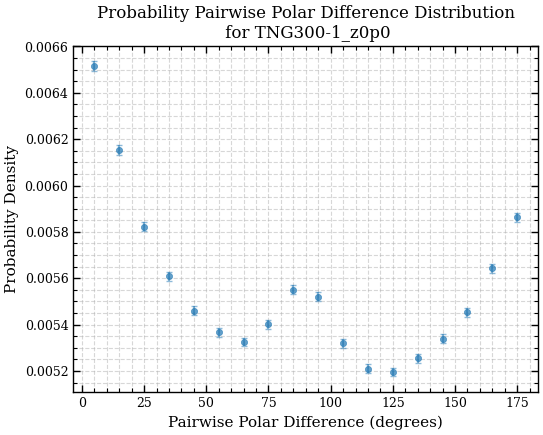

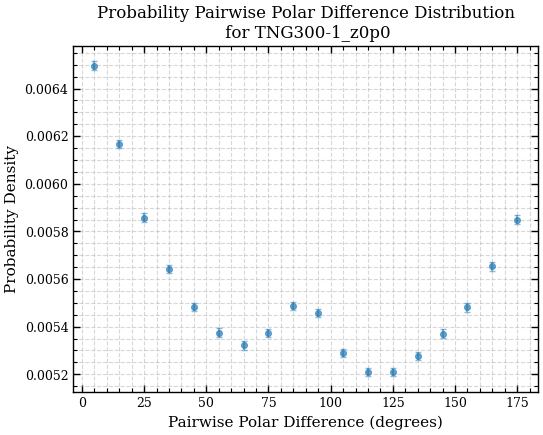

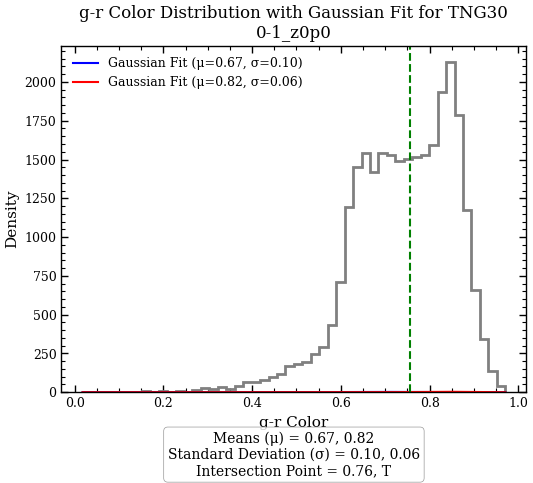

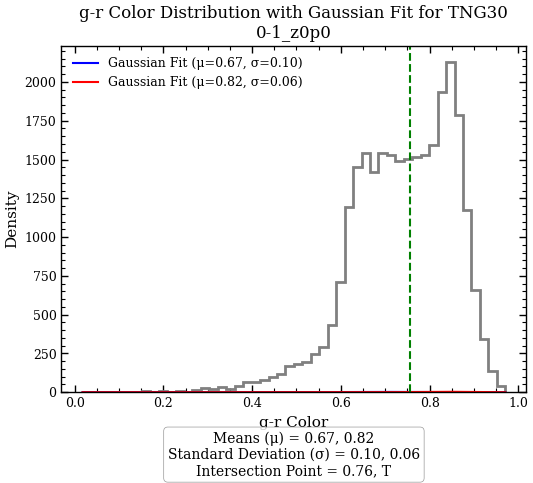

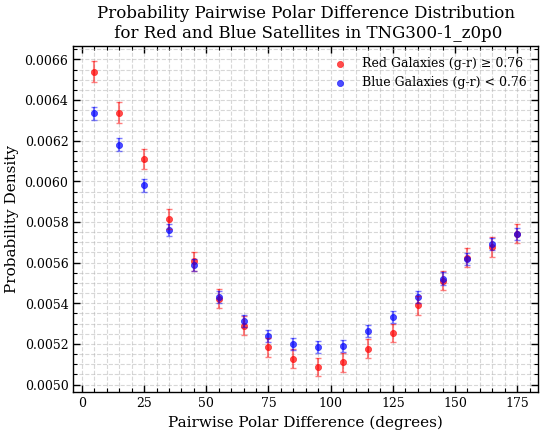

In [17]:
galaxyAnalysisOriginal.setGeneralRewrite(True)
galaxyAnalysisOriginal.pairwisePolarDifferencePlot(galaxyAnalysisOriginal.loaded_list_of_galaxy_groupsRaw)
galaxyAnalysisOriginal.pairwisePolarDifferencePlot(galaxyAnalysisOriginal.filtered_gt14_list_of_galaxy_groups)
galaxyAnalysisOriginal.redVsBlueDistributionPlot(galaxyAnalysisOriginal.filtered_gt14_list_of_galaxy_groups)
galaxyAnalysisOriginal.redVsBluePairwisePlot(galaxyAnalysisOriginal.filtered_gt14_list_of_galaxy_groups)
galaxyAnalysisOriginal.setGeneralRewrite(False)